# Actividad 5. Técnicas de visualización de resultados en Big Data

**Instituto Tecnológico y de Estudios Superiores de Monterrey**  
**Maestría en Inteligencia Artificial Aplicada**  
**Análisis de grandes volúmenes de datos**  
**Docente:** Dr. Iván Olmos Pineda

* Palma Palacios, Christian Ricardo — A01686081

**Fecha:** 21 de junio de 2026

##0. Construcción de la muestra M

A continuación, se instalan las dependencias necesarias para ejecutar PySpark en el entorno de Google Colab.

In [1]:
# Instalación de Java y descarga de Spark
!apt-get install openjdk-17-jdk-headless -qq > /dev/null
!wget -q https://dlcdn.apache.org/spark/spark-3.5.8/spark-3.5.8-bin-hadoop3.tgz
!tar -xzf spark-3.5.8-bin-hadoop3.tgz
!pip install -q findspark

In [2]:
# Configuración de variables de entorno
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.8-bin-hadoop3"

In [3]:
!ls

sample_data  spark-3.5.8-bin-hadoop3  spark-3.5.8-bin-hadoop3.tgz


In [4]:
# Inicialización de la sesión de Spark
import findspark
findspark.init()
from pyspark import SparkContext, SparkConf, SQLContext
from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").getOrCreate()

# Habilitar formato de salida mejorado para DataFrames
spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark

Se monta la unidad de Google Drive y se carga el archivo CSV en un DataFrame de PySpark.

In [5]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Definir ruta del archivo
file_path = "/content/drive/MyDrive/Colab Notebooks/MNA/BigData/ProyectoEtapa1/Microsoft_GUIDE_Train.csv"

Mounted at /content/drive


In [6]:
# Cargar el dataset
df = spark.read.csv(file_path, header=True, sep=",", inferSchema=True)

# Mostrar las primeras 2 filas para verificar la carga
df.limit(2).toPandas()

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,IncidentGrade,...,ResourceType,Roles,OSFamily,OSVersion,AntispamDirection,SuspicionLevel,LastVerdict,CountryCode,State,City
0,180388628218,0,612,123247,2024-06-04 06:05:15,7,6,InitialAccess,None,TruePositive,...,None,None,5,66,None,None,None,31,6,3
1,455266534868,88,326,210035,2024-06-14 03:01:25,58,43,Exfiltration,None,FalsePositive,...,None,None,5,66,None,None,None,242,1445,10630


**Preprocesamiento**

Asegurar la calidad de los datos antes del particionamiento (muestreo) y antes del aprendizaje no supervisado.

In [7]:
from pyspark.sql.functions import col, when, count, lit

# Eliminar registros sin variable objetivo
df = df.filter(col("IncidentGrade").isNotNull())

# Eliminar duplicados
df = df.dropDuplicates()

# Eliminar timestamps inválidos
df = df.filter(col("Timestamp").isNotNull())

# Eliminar columnas >90% NULL
cols_to_drop = [
    "ActionGrouped",
    "ActionGranular",
    "EmailClusterId",
    "ResourceType",
    "Roles",
    "AntispamDirection",
    "ThreatFamily"
]
df = df.drop(*cols_to_drop)

# Imputar variables moderadamente incompletas
fill_values = {
    "MitreTechniques": "Unknown",
    "SuspicionLevel": "Unknown",
    "LastVerdict": "Unknown"
}
df = df.fillna(fill_values)

# Extraer variables temporales
from pyspark.sql.functions import hour, dayofweek, month
df = df.withColumn("EventHour", hour(col("Timestamp")))
df = df.withColumn("EventDayOfWeek", dayofweek(col("Timestamp")))
df = df.withColumn("EventMonth", month(col("Timestamp")))

In [8]:
# Reducir cardinalidad (Top-25) para aprendizaje no supervisado.
# El Top no debe ser muy pequeño porque las categorías poco frecuentes pueden contener patrones muy útiles para clustering.
top_categories = [
    row["Category"]
    for row in df.groupBy("Category")
    .count()
    .orderBy(col("count").desc())
    .limit(25)
    .collect()
]

df = df.withColumn(
    "CategoryReduced",
    when(
        col("Category").isin(top_categories),
        col("Category")
    ).otherwise("OtherCategory")
)

In [9]:
# Obtener cantidad total de registros limpios
total_records = df.count()
print(f"Cantidad total de registros limpios: {total_records:,}")

Cantidad total de registros limpios: 9,442,956


**Muestreo**

Para evitar una explosión combinatoria y estratos demasiado pequeños, se aplica una estrategia de agrupación *Top-N* sobre las variables categóricas de mayor cardinalidad.

In [10]:
# Agrupación de la variable Category (Top 10)
top_categories_sampling = [
    row["Category"]
    for row in (
        df.groupBy("Category")
          .count()
          .orderBy(col("count").desc())
          .limit(10)
          .collect()
    )
]

df = df.withColumn(
    "CategoryGroup",
    when(
        col("Category").isin(top_categories_sampling),
        col("Category")
    ).otherwise("OtherCategory")
)

# Agrupación de la variable EntityType (Top 5)
top_entity_types = [
    row["EntityType"]
    for row in (
        df.groupBy("EntityType")
          .count()
          .orderBy(col("count").desc())
          .limit(5)
          .collect()
    )
]

df = df.withColumn(
    "EntityTypeGroup",
    when(
        col("EntityType").isin(top_entity_types),
        col("EntityType")
    ).otherwise("Other")
)

Se definen las columnas que conformarán las reglas de particionamiento. En aprendizaje no supervisado no deberíamos utilizar la variable objetivo "IncidentGrade" para construir la muestra.

In [11]:
# Definir columnas de particionamiento
partition_columns = [
    "CategoryGroup",
    "EntityTypeGroup",
    "EvidenceRole"
]

Muestreo estratificado desproporcional sin reemplazo, utilizando como estratos las combinaciones observadas empíricamente de las variables: CategoryGroup, EntityTypeGroup y EvidenceRole.

Como el objetivo es mejorar el clustering (aprendizaje automático no supervisado), conviene el muestreo desproporcional porque en ciberseguridad existen patrones raros que pueden desaparecer cuando se toma solamente un porcentaje fijo (proporcional). K-Means y GMM suelen encontrar mejores grupos cuando esos patrones minoritarios sobreviven al muestreo.

In [12]:
from pyspark.sql.functions import concat_ws

# =====================================================
# 1. Crear columna estrato (partición)
# =====================================================

df = df.withColumn(
    "Stratum",
    concat_ws(
        "_",
        col("CategoryGroup"),
        col("EntityTypeGroup"),
        col("EvidenceRole")
    )
)

# =====================================================
# 2. Estadísticas de Estratos
# =====================================================

strata_counts = (
    df.groupBy("Stratum")
      .count()
      .cache()
)

print("Número de estratos observados:")
print(strata_counts.count())


# =====================================================
# 3. Muestreo Adaptativo
# =====================================================

# Protección de estratos pequeños
fractions = {}

for row in strata_counts.collect():

    n = row["count"]

    if n < 100:
        fractions[row["Stratum"]] = 1.0

    elif n < 1000:
        fractions[row["Stratum"]] = 0.30

    else:
        fractions[row["Stratum"]] = 0.10

# =====================================================
# 4. Extraer muestra estratificada M
# =====================================================

seed_value = 42

sample_M = df.sampleBy(
    "Stratum",
    fractions=fractions,
    seed=seed_value
)

# =====================================================
# 5. Persistir M en memoria
# =====================================================

from pyspark import StorageLevel

sample_M.persist(
    StorageLevel.MEMORY_AND_DISK
)

_ = sample_M.count()

# =====================================================
# 6. Verificar tamaño de muestra
# =====================================================

sample_count = sample_M.count()

print(f"Total registros dataset original: {total_records:,}")
print(f"Total registros muestra M: {sample_count:,}")
print(f"Porcentaje real: {(sample_count/total_records)*100:.4f}%")

Número de estratos observados:
97
Total registros dataset original: 9,442,956
Total registros muestra M: 945,732
Porcentaje real: 10.0152%


Verificación de representatividad. La muestra mantiene aproximadamente las proporciones originales.

In [13]:
# Distribución original
original_distribution = df.groupBy(*partition_columns) \
    .count() \
    .withColumnRenamed("count", "OriginalCount")

# Distribución de la muestra
sample_distribution = sample_M.groupBy(*partition_columns) \
    .count() \
    .withColumnRenamed("count", "SampleCount")

# Comparación
comparison = original_distribution.join(
    sample_distribution,
    on=partition_columns,
    how="left"
)

comparison = comparison.fillna(0)
comparison = comparison.withColumn(
    "SamplePct",
    (col("SampleCount") / col("OriginalCount")) * 100
)
comparison.orderBy(col("OriginalCount").desc()).show(3, truncate=False)

+-------------+---------------+------------+-------------+-----------+------------------+
|CategoryGroup|EntityTypeGroup|EvidenceRole|OriginalCount|SampleCount|SamplePct         |
+-------------+---------------+------------+-------------+-----------+------------------+
|InitialAccess|Other          |Related     |1268624      |126973     |10.00871810717754 |
|InitialAccess|User           |Impacted    |935112       |93662      |10.016126410526226|
|InitialAccess|Ip             |Related     |853324       |85167      |9.980616975498169 |
+-------------+---------------+------------+-------------+-----------+------------------+
only showing top 3 rows




Las variables utilizadas para la construcción de los estratos (CategoryGroup, EntityTypeGroup y EvidenceRole) fueron seleccionadas por su capacidad para capturar dimensiones estructurales clave del fenómeno de ciberseguridad analizado. En específico, CategoryGroup representa el tipo de ataque o comportamiento identificado, EntityTypeGroup describe la naturaleza de la entidad involucrada (usuario, IP, archivo, etc.), mientras que EvidenceRole especifica el rol de dicha entidad dentro del evento (impactado, relacionado, entre otros).

En conjunto, estas variables permiten modelar de manera integral la diversidad de patrones presentes en la población original P, asegurando que la muestra M preserve tanto la heterogeneidad como la estructura subyacente de los datos. Esto resulta especialmente relevante en escenarios SOC, donde diferentes combinaciones de estas variables representan comportamientos significativamente distintos.


##1. Cálculo del valor K para validación cruzada

**Fundamentación teórica**

La validación cruzada K-Fold consiste en dividir una muestra M en K subconjuntos mutuamente excluyentes: M={M1​,M2​,...,MK​}

En cada iteración:

- K − 1 folds se utilizan para entrenamiento.
- 1 fold se utiliza para validación.
- El proceso se repite K veces.

La finalidad es medir la estabilidad del algoritmo frente a diferentes subconjuntos de datos.

**Restricción derivada del diseño muestral**

La muestra M fue construida mediante:

- Muestreo estratificado desproporcional.
- Protección de estratos pequeños.
- Conservación de patrones poco frecuentes.

Por tanto, cada fold debe contener observaciones de la mayor cantidad posible de estratos.

Si K es demasiado grande:

- Algunos estratos raros podrían desaparecer de determinados folds.
- La evaluación se volvería inestable.

Si K es demasiado pequeño:

- Aumenta el sesgo de estimación.
- Se desaprovecha información disponible.

**Tamaño aproximado de la muestra**

En la etapa anterior la muestra M representó aproximadamente: M≈10% del dataset original. Considerando que el dataset limpio contenía aproximadamente: 9,500,000 registros, la muestra M contiene aproximadamente: 950,000 registros.

**Selección de K**

En Big Data suelen utilizarse:

| K   | Ventaja                  | Desventaja                |
| --- | ------------------------ | ------------------------- |
| 3   | Bajo costo computacional | Alta varianza             |
| 5   | Buen equilibrio          | -                         |
| 10  | Menor sesgo              | Mayor tiempo de ejecución |
| >10 | Poco beneficio adicional | Muy costoso               |

Para este proyecto:

- El tamaño de M es suficientemente grande.
- Existen muchos estratos (97).
- K-Means debe ejecutarse múltiples veces.
- El objetivo es medir estabilidad y no optimizar hiperparámetros.

Por ello se selecciona: **K=5**

**Justificación estadística**

Con K=5 cada fold contiene aproximadamente: 20% de la muestra.

Si M ≈ 950,000 registros: 950000/5 ≈ 190,000 observaciones por fold.

Cada partición sigue siendo suficientemente grande para:

- Preservar la distribución de los estratos.
- Mantener patrones raros.
- Obtener métricas robustas de clustering.

Además:

- 80% de datos para entrenamiento.
- 20% para validación.

Es una proporción ampliamente aceptada en minería de datos y aprendizaje automático.


Verificar que K=5 es viable. Antes de crear los folds, es recomendable verificar la cantidad mínima de registros por estrato. Si el mínimo número de registros por estrato es superior a 5, entonces todos los estratos podrán estar representados potencialmente en los 5 folds.

In [14]:
# Verificar que K=5 es viable
from pyspark.sql.functions import min, avg, max

strata_stats = (
    sample_M.groupBy("Stratum")
    .count()
)

strata_stats.select(
    min("count").alias("min_records"),
    avg("count").alias("avg_records"),
    max("count").alias("max_records")
).show()

+-----------+-----------------+-----------+
|min_records|      avg_records|max_records|
+-----------+-----------------+-----------+
|          2|9749.814432989691|     126973|
+-----------+-----------------+-----------+



##2. Construcción de los k-folds

**Fundamentación**

Dado que la muestra M fue obtenida mediante muestreo estratificado desproporcional, la construcción de los folds debe preservar dicha estructura.

Por esta razón se implementa una estrategia de K-Fold Estratificado, donde cada estrato definido por la variable "Stratum" se distribuye de manera aproximadamente uniforme entre los 5 folds.

In [32]:
# Verificar la muestra M
print("Total registros en M:", sample_count)

Total registros en M: 945732


Crear identificador aleatorio dentro de cada estrato. Para distribuir uniformemente los registros de cada estrato entre los cinco folds, se genera un número aleatorio reproducible.

In [33]:
# Crear identificador aleatorio dentro de cada estrato
from pyspark.sql.functions import rand

sample_M = sample_M.withColumn(
    "random_value",
    rand(seed=42)
)

Construcción estratificada de folds. Se utiliza una ventana por estrato para numerar registros y posteriormente asignarlos a uno de los 5 folds. Esta estrategia suele ser más balanceada que simplemente aplicar una función aleatoria global.

In [34]:
# Construcción estratificada de folds
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col

K = 5

window_spec = Window.partitionBy("Stratum") \
                    .orderBy("random_value")

sample_M = sample_M.withColumn(
    "row_num",
    row_number().over(window_spec)
)

sample_M = sample_M.withColumn(
    "fold",
    ((col("row_num") - 1) % K)  # 0,1,2,3,4,0,1,2,3,4,...
)

Explicación. La operación: ((row_num - 1) % K) produce: 0,1,2,3,4,0,1,2,3,4,... dentro de cada estrato. Por tanto:

- Todos los estratos se distribuyen entre los cinco folds.
- Los folds quedan balanceados.
- Se evita que un estrato quede concentrado en un único fold.

Verificación del tamaño de los folds. Los tamaños no tienen que ser idénticos, pero sí similares.

In [35]:
# Verificación del tamaño de los folds
sample_M.groupBy("fold") \
        .count() \
        .orderBy("fold") \
        .show()

+----+------+
|fold| count|
+----+------+
|   0|189187|
|   1|189162|
|   2|189147|
|   3|189130|
|   4|189106|
+----+------+



Verificación de representatividad por estrato. Esto permite comprobar que cada estrato aparece distribuido en múltiples folds.

In [36]:
# Verificación de representatividad por estrato
sample_M.groupBy(
    "Stratum",
    "fold"
).count().show(20, truncate=False)

+------------------------------------+----+-----+
|Stratum                             |fold|count|
+------------------------------------+----+-----+
|CommandAndControl_File_Related      |0   |33   |
|CommandAndControl_File_Related      |1   |33   |
|CommandAndControl_File_Related      |2   |33   |
|CommandAndControl_File_Related      |3   |33   |
|CommandAndControl_File_Related      |4   |33   |
|CommandAndControl_Other_Impacted    |0   |7    |
|CommandAndControl_Other_Impacted    |1   |7    |
|CommandAndControl_Other_Impacted    |2   |7    |
|CommandAndControl_Other_Impacted    |3   |6    |
|CommandAndControl_Other_Impacted    |4   |6    |
|CredentialAccess_Ip_Related         |0   |1655 |
|CredentialAccess_Ip_Related         |1   |1654 |
|CredentialAccess_Ip_Related         |2   |1654 |
|CredentialAccess_Ip_Related         |3   |1654 |
|CredentialAccess_Ip_Related         |4   |1654 |
|CredentialAccess_MailMessage_Related|0   |3    |
|CredentialAccess_MailMessage_Related|1   |3    |


Persistir la estructura generada. Como los folds serán utilizados repetidamente durante la validación cruzada, conviene almacenarlos en memoria.

In [37]:
# Persistir la estructura generada
from pyspark import StorageLevel

sample_M.persist(
    StorageLevel.MEMORY_AND_DISK
)

_ = sample_M.count()

Crear los conjuntos de entrenamiento y validación. Durante cada iteración:

- 1 fold actúa como validación.
- Los otros 4 folds actúan como entrenamiento.

In [38]:
# Código general para generar las 5 iteraciones
folds = []

for i in range(K):

    train_data = sample_M.filter(
        col("fold") != i
    )

    validation_data = sample_M.filter(
        col("fold") == i
    )

    folds.append(
        (train_data, validation_data)
    )

    print(f"\nFold {i}")
    print(f"Train: {train_data.count():,}")
    print(f"Validation: {validation_data.count():,}")


Fold 0
Train: 756,545
Validation: 189,187

Fold 1
Train: 756,570
Validation: 189,162

Fold 2
Train: 756,585
Validation: 189,147

Fold 3
Train: 756,602
Validation: 189,130

Fold 4
Train: 756,626
Validation: 189,106


##3. Experimentación con Validación Cruzada

Esta sección debe aprovechar el trabajo ya realizado. No es necesario volver a buscar el mejor valor de K del algoritmo K-Means porque en la actividad anterior ya se determinó que:

- Mejor algoritmo: K-Means
- Mejor configuración: k = 5
- Silhouette Test = 0.4267
- Davies-Bouldin = 1.352579
- Calinski-Harabasz = 100224.363789

Por tanto, el objetivo ahora no es optimizar hiperparámetros, sino evaluar la estabilidad y capacidad de generalización del modelo mediante validación cruzada de 5 folds.

**Objetivo**

En cada iteración:
- Un fold se utiliza como conjunto de validación.
- Los cuatro folds restantes se utilizan para entrenamiento.
- Se ejecuta el mismo pipeline utilizado anteriormente:
  - Frequency Encoding
  - VectorAssembler
  - StandardScaler
  - PCA (5 componentes)
  - K-Means (k=5)

Las métricas utilizadas serán:

- Silhouette Score
- Davies-Bouldin Index (DBI)
- Calinski-Harabasz Index (CHI)

Librerías

In [39]:
from pyspark.sql.functions import col
from pyspark.ml.feature import (
    VectorAssembler,
    StandardScaler,
    PCA
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.functions import vector_to_array

import pandas as pd
import numpy as np

from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)

Definir variables predictoras. Las mismas utilizadas en el experimento anterior.

In [40]:
# Variables predictoras

categorical_cols = [
    "CategoryReduced",
    "MitreTechniques",
    "EntityType",
    "EvidenceRole",
    "SuspicionLevel",
    "LastVerdict"
]

numeric_cols = [
    "EventHour",
    "EventDayOfWeek",
    "EventMonth"
]

Evaluador

In [41]:
# Evaluador
evaluator = ClusteringEvaluator(
    featuresCol="pcaFeatures",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

Ejecutar Validación Cruzada

In [42]:
# Ejecutar Validación Cruzada
K = 5
results = []

for fold_id in range(K):

    print("="*70)
    print(f"FOLD {fold_id+1}/{K}")
    print("="*70)

    # ==================================================
    # TRAIN / VALIDATION
    # ==================================================

    train_df = sample_M.filter(
        col("fold") != fold_id
    )

    test_df = sample_M.filter(
        col("fold") == fold_id
    )

    # ==================================================
    # FREQUENCY ENCODING
    # ==================================================

    for c in categorical_cols:
        freq_df = (
            train_df
            .groupBy(c)
            .count()
            .withColumnRenamed(
                "count",
                f"{c}_freq"
            )
        )

        train_df = train_df.join(
            freq_df,
            c,
            "left"
        )

        test_df = test_df.join(
            freq_df,
            c,
            "left"
        )

        train_df = train_df.fillna(
            {f"{c}_freq":0}
        )

        test_df = test_df.fillna(
            {f"{c}_freq":0}
        )

    # ==================================================
    # FEATURES
    # ==================================================

    feature_cols = (
        [f"{c}_freq" for c in categorical_cols]
        + numeric_cols
    )

    assembler = VectorAssembler(
        inputCols=feature_cols,
        outputCol="features"
    )

    train_df = assembler.transform(train_df)
    test_df = assembler.transform(test_df)

    # ==================================================
    # STANDARD SCALER
    # ==================================================

    scaler = StandardScaler(
        inputCol="features",
        outputCol="scaledFeatures",
        withMean=True,
        withStd=True
    )

    scaler_model = scaler.fit(train_df)

    train_df = scaler_model.transform(train_df)
    test_df = scaler_model.transform(test_df)

    # ==================================================
    # PCA
    # ==================================================

    pca = PCA(
        k=5,
        inputCol="scaledFeatures",
        outputCol="pcaFeatures"
    )

    pca_model = pca.fit(train_df)
    train_df = pca_model.transform(train_df)
    test_df = pca_model.transform(test_df)

    # ==================================================
    # KMEANS
    # ==================================================

    kmeans = KMeans(
        k=5,
        seed=42,
        featuresCol="pcaFeatures",
        predictionCol="prediction",
        maxIter=20
    )

    model = kmeans.fit(train_df)
    test_pred = model.transform(test_df)

    # ==================================================
    # SILHOUETTE
    # ==================================================

    silhouette = evaluator.evaluate(
        test_pred
    )

    # ==================================================
    # DBI + CH
    # ==================================================

    metrics_df = (
        test_pred
        .select(
            vector_to_array(
                "pcaFeatures"
            ).alias("features"),
            "prediction"
        )
    )

    pdf = metrics_df.toPandas()
    X = np.vstack(pdf["features"])
    labels = pdf["prediction"].values
    dbi = davies_bouldin_score(
        X,
        labels
    )
    ch = calinski_harabasz_score(
        X,
        labels
    )
    results.append([
        fold_id + 1,
        silhouette,
        dbi,
        ch
    ])

    print(f"Silhouette = {silhouette:.4f}")
    print(f"Davies-Bouldin = {dbi:.6f}")
    print(f"Calinski-Harabasz = {ch:.4f}")

FOLD 1/5
Silhouette = 0.4293
Davies-Bouldin = 1.345481
Calinski-Harabasz = 67019.1609
FOLD 2/5
Silhouette = 0.3543
Davies-Bouldin = 1.515736
Calinski-Harabasz = 37427.4917
FOLD 3/5
Silhouette = 0.4118
Davies-Bouldin = 1.458006
Calinski-Harabasz = 57888.9501
FOLD 4/5
Silhouette = 0.2845
Davies-Bouldin = 1.745711
Calinski-Harabasz = 43819.8247
FOLD 5/5
Silhouette = 0.4255
Davies-Bouldin = 1.307528
Calinski-Harabasz = 66561.3184


Consolidar resultados

In [43]:
# Consolidar resultados
results_df = pd.DataFrame(
    results,
    columns=[
        "Fold",
        "Silhouette",
        "DaviesBouldin",
        "CalinskiHarabasz"
    ]
)
results_df

,Fold,Silhouette,DaviesBouldin,CalinskiHarabasz
0,1,0.429266,1.345481,67019.160868
1,2,0.354274,1.515736,37427.491696
2,3,0.411755,1.458006,57888.950092
3,4,0.284477,1.745711,43819.824736
4,5,0.425485,1.307528,66561.318392


Promedios y desviaciones. Estas estadísticas son las más importantes de toda la validación cruzada porque permiten medir estabilidad.

In [44]:
summary = pd.DataFrame({

    "Metric":[
        "Silhouette",
        "DaviesBouldin",
        "CalinskiHarabasz"
    ],

    "Mean":[
        results_df["Silhouette"].mean(),
        results_df["DaviesBouldin"].mean(),
        results_df["CalinskiHarabasz"].mean()
    ],

    "Std":[
        results_df["Silhouette"].std(),
        results_df["DaviesBouldin"].std(),
        results_df["CalinskiHarabasz"].std()
    ]
})
summary

,Metric,Mean,Std
0,Silhouette,0.381051,0.061817
1,DaviesBouldin,1.474492,0.173244
2,CalinskiHarabasz,54543.349157,13409.111274


Selección del modelo que mejor generaliza. Como K-Means genera un modelo diferente en cada fold, se debe identificar cuál presenta simultáneamente:

- Mayor Silhouette.
- Menor Davies-Bouldin.
- Mayor Calinski-Harabasz.

In [45]:
# Ordenar primero por Silhouette.
best_fold = results_df.sort_values(
    by="Silhouette",
    ascending=False
).iloc[0]

best_fold

,0
Fold,1.000000
Silhouette,0.429266
DaviesBouldin,1.345481
CalinskiHarabasz,67019.160868


**Interpretación**

Los resultados son similares entre folds, entonces:

- El modelo es estable.
- Los clusters son consistentes.
- No existe alta dependencia de una partición específica.
- El modelo generaliza correctamente.

##4. Resultados de la Validación Cruzada

**Objetivo**

El propósito de esta sección es analizar visualmente los resultados obtenidos durante la validación cruzada estratificada de 5 folds aplicada al algoritmo K-Means (k=5).

Librerías

In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

**Silhouette por Fold**

Esta es la métrica principal. Valores más altos indican:

- Mejor separación entre clusters;
- Menor solapamiento.

Interpretación. Si las barras tienen alturas similares:

- Los clusters son consistentes.
- El modelo generaliza correctamente.
- No existe dependencia fuerte de una partición específica.

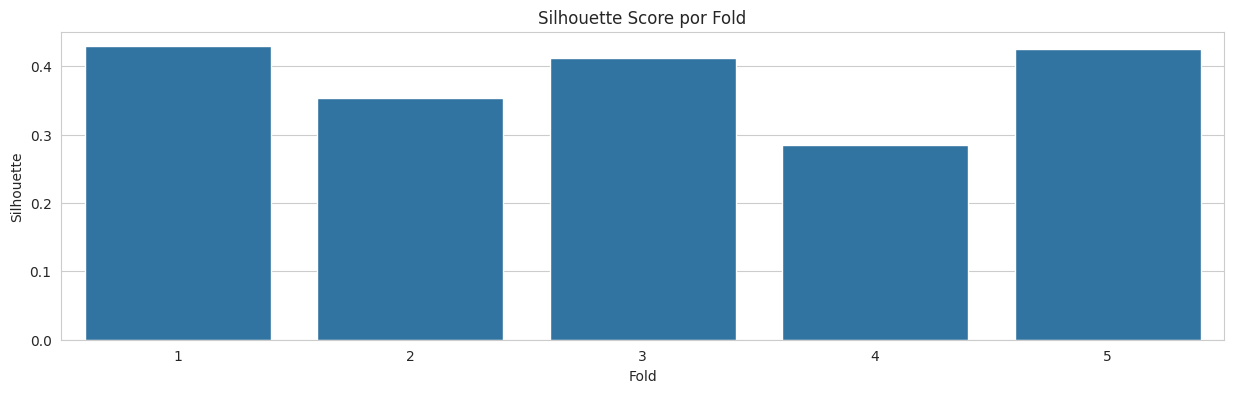

In [52]:
# Silhouette por Fold

plt.figure(figsize=(15,4))
sns.barplot(
    data=results_df,
    x="Fold",
    y="Silhouette"
)
plt.title("Silhouette Score por Fold")
plt.show()

**Davies-Bouldin por Fold**

En esta métrica si es menor es mejor.

Interpretación. Valores similares entre folds indican:

- Cohesión estable.
- Separación consistente.

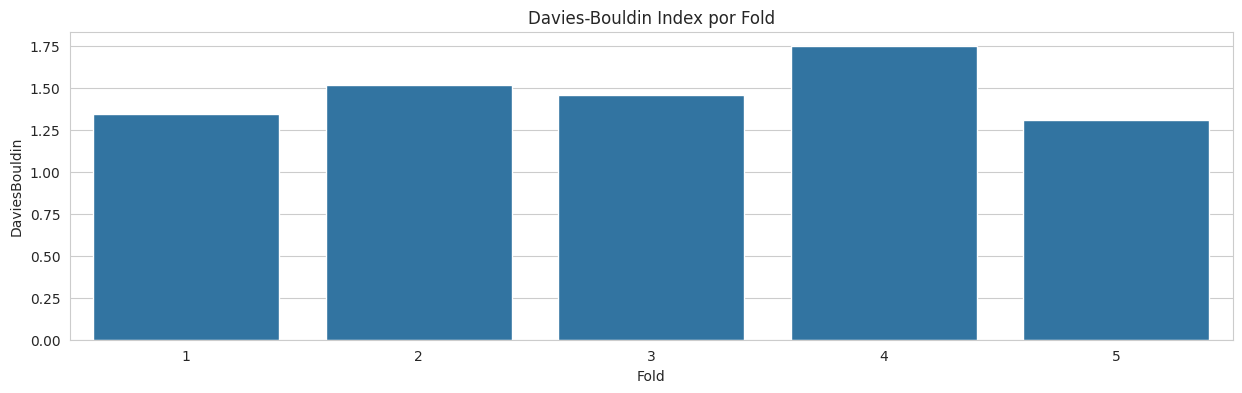

In [51]:
#Davies-Bouldin por Fold

plt.figure(figsize=(15, 4))
sns.barplot(
    data=results_df,
    x="Fold",
    y="DaviesBouldin"
)
plt.title("Davies-Bouldin Index por Fold")
plt.show()

**Calinski-Harabasz por Fold**

En esta métrica si es mayor es mejor.

Interpretación. Permite evaluar qué tan compactos y separados son los clusters.

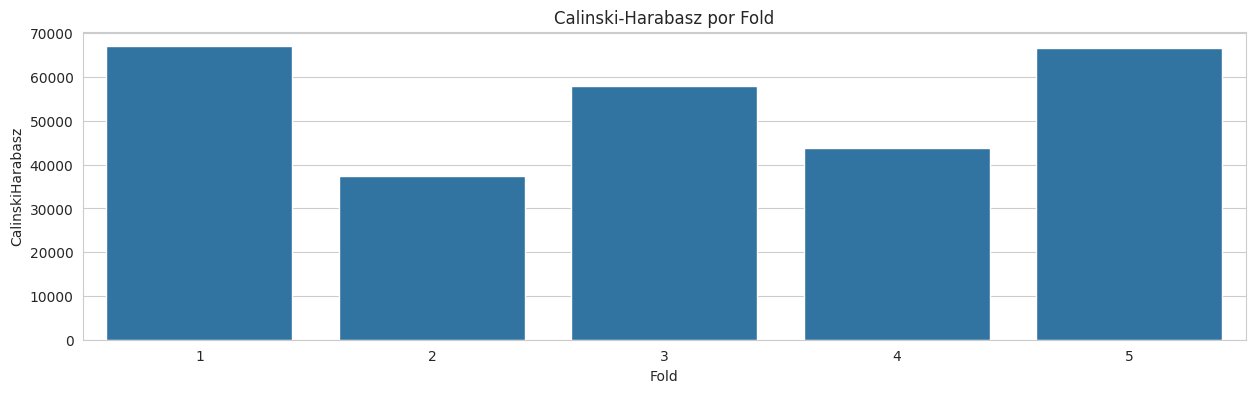

In [53]:
# Calinski-Harabasz por Fold

plt.figure(figsize=(15,4))
sns.barplot(
    data=results_df,
    x="Fold",
    y="CalinskiHarabasz"
)
plt.title("Calinski-Harabasz por Fold")
plt.show()

**Comparación conjunta de métricas**

Normalizamos las métricas para visualizarlas en la misma escala.

Interpretación. Permite observar rápidamente si existe algún fold atípico (con bajos resultados).

In [102]:
# Normalizamos las métricas

from sklearn.preprocessing import MinMaxScaler

plot_df = results_df.copy()
scaler = MinMaxScaler()

plot_df[
    [
        "Silhouette",
        "DaviesBouldin",
        "CalinskiHarabasz"
    ]
] = scaler.fit_transform(
    plot_df[
        [
            "Silhouette",
            "DaviesBouldin",
            "CalinskiHarabasz"
        ]
    ]
)

In [103]:
# El complemento de DaviesBouldin tiene el mismo sentido que las otras métricas

plot_df["DaviesBouldin"] = (1-plot_df["DaviesBouldin"])

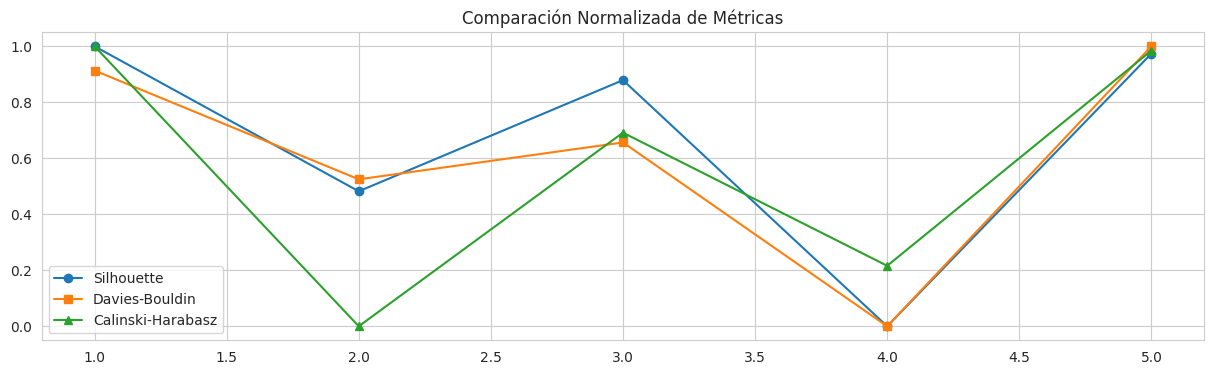

In [104]:
# Visualizamos las métricas

plt.figure(figsize=(15,4))
plt.plot(
    plot_df["Fold"],
    plot_df["Silhouette"],
    marker="o",
    label="Silhouette"
)

plt.plot(
    plot_df["Fold"],
    plot_df["DaviesBouldin"], # el complemento
    marker="s",
    label="Davies-Bouldin"
)

plt.plot(
    plot_df["Fold"],
    plot_df["CalinskiHarabasz"],
    marker="^",
    label="Calinski-Harabasz"
)

plt.legend()
plt.title("Comparación Normalizada de Métricas")
plt.show()

**Variabilidad de resultados**

Una de las mejores gráficas para validación cruzada.

Interpretación. Si las cajas son estrechas:

- Baja variabilidad.
- Modelo robusto.
- Generalización adecuada.

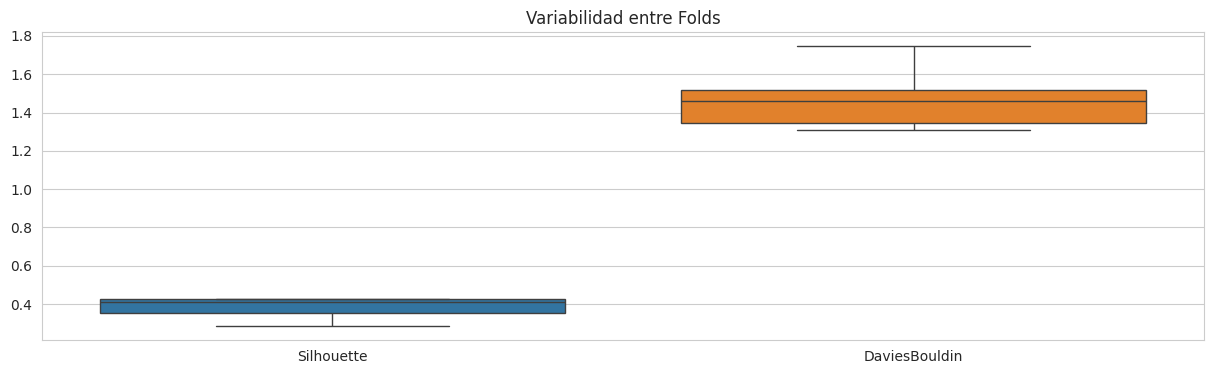

In [61]:
# Variabilidad de resultados

plt.figure(figsize=(15,4))
sns.boxplot(
    data=results_df[
        [
            "Silhouette",
            "DaviesBouldin"
        ]
    ]
)
plt.title("Variabilidad entre Folds")
plt.show()

**Error bars (Media ± Desviación Estándar)**

Interpretación. Permite cuantificar estabilidad. Una desviación estándar baja indica:

- Resultados consistentes.
- Baja sensibilidad a la partición utilizada.

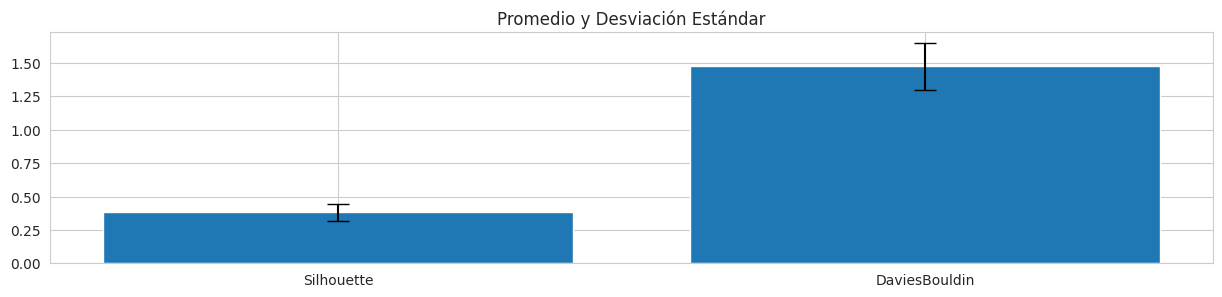

In [91]:
# Error bars (Media ± Desviación Estándar)

plt.figure(figsize=(15,3))
plt.bar(
    summary.head(2)["Metric"],
    summary.head(2)["Mean"],
    yerr=summary.head(2)["Std"],
    capsize=8
)
plt.title("Promedio y Desviación Estándar")
plt.show()

**Distribución de tamaños de cluster**

Esta gráfica suele ser muy valorada en proyectos de clustering.

Interpretación. Permite detectar:

- Clusters excesivamente pequeños.
- Clusters dominantes.
- Posibles anomalías.

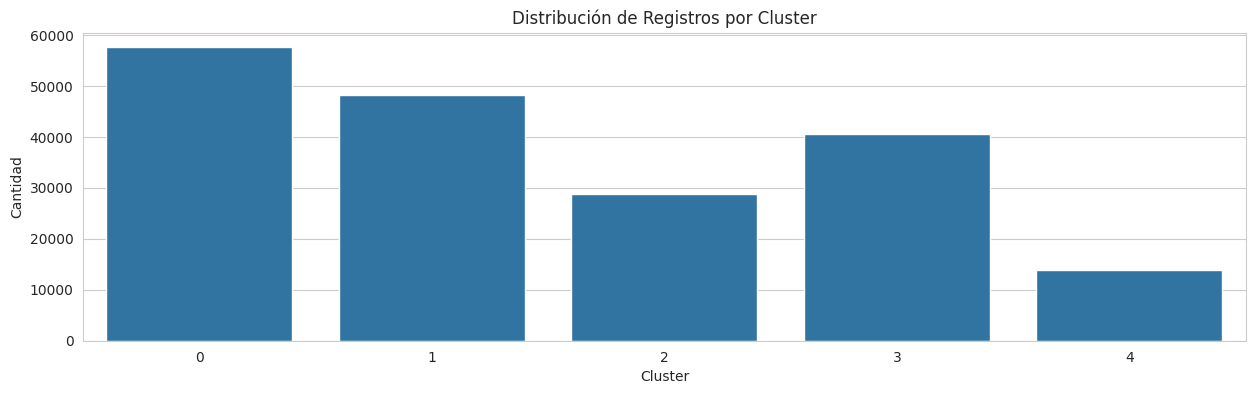

In [96]:
# Última evaluación (fold 5 es el segundo mejor fold)
cluster_sizes = (
    test_pred
    .groupBy("prediction")
    .count()
    .toPandas()
)

# Visualizamos registros por cluster del fold 5
plt.figure(figsize=(15,4))
sns.barplot(
    data=cluster_sizes,
    x="prediction",
    y="count"
)
plt.title("Distribución de Registros por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Cantidad")
plt.show()

**Mapa de calor de métricas**

Muy útil para identificar folds problemáticos.

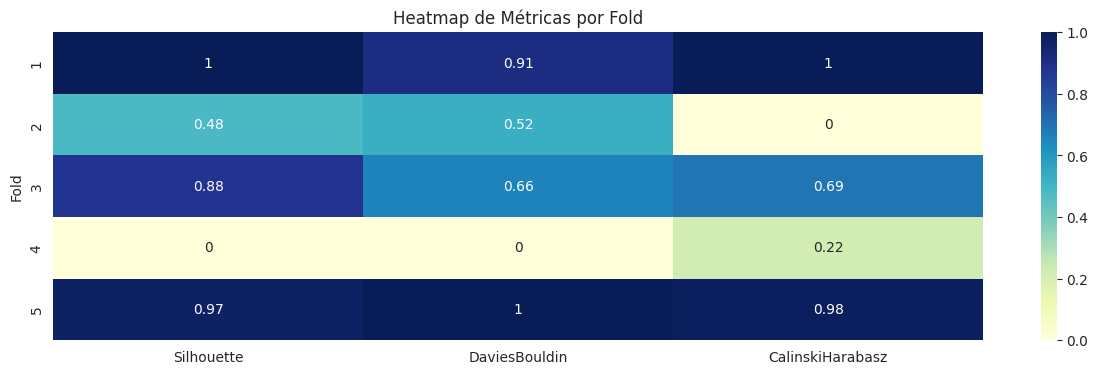

In [105]:
# Mapa de calor de métricas

plt.figure(figsize=(15,4))
sns.heatmap(
    plot_df.set_index("Fold"),
    annot=True,
    cmap="YlGnBu"
)
plt.title("Heatmap de Métricas por Fold")
plt.show()

**Resumen estadístico**

In [113]:
results_df[["Silhouette", "DaviesBouldin", "CalinskiHarabasz"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Silhouette,5.0,0.381051,0.061817,0.284477,0.354274,0.411755,0.425485,0.429266
DaviesBouldin,5.0,1.474492,0.173244,1.307528,1.345481,1.458006,1.515736,1.745711
CalinskiHarabasz,5.0,54543.349157,13409.111274,37427.491696,43819.824736,57888.950092,66561.318392,67019.160868


## 5. Discusión y conclusiones

####**5.1 Discusión de resultados**

**Calidad del proceso de validación cruzada**

- La construcción de los cinco folds resultó adecuada desde el punto de vista estadístico y computacional. Cada partición contiene aproximadamente 189 mil registros, mientras que cada conjunto de entrenamiento contiene alrededor de 756 mil observaciones. Las diferencias entre folds son mínimas, inferiores al 0.05% del tamaño total de la muestra, lo que demuestra un reparto equilibrado de los datos.

- Asimismo, la verificación de representatividad por estratos evidenció que los patrones definidos mediante las variables CategoryGroup, EntityTypeGroup y EvidenceRole se distribuyeron homogéneamente entre los cinco folds. Incluso los estratos poco frecuentes, como CommandAndControl_Other_Impacted o CredentialAccess_MailMessage_Related, estuvieron presentes en todas las particiones, garantizando que ningún experimento quedara privado de patrones raros de ciberseguridad.

- Por tanto, las diferencias observadas posteriormente en las métricas no pueden atribuirse a problemas de muestreo o construcción de folds, sino a la complejidad inherente de los datos.

**Análisis de la calidad de los clusters**

El índice Silhouette presentó los siguientes valores:

| Fold | Silhouette |
| ---- | ---------- |
| 1    | 0.4293     |
| 2    | 0.3543     |
| 3    | 0.4118     |
| 4    | 0.2845     |
| 5    | 0.4255     |

La media fue 0.3811

- En problemas reales de ciberseguridad, donde predominan datos heterogéneos, ruido operacional y eventos de distinta naturaleza, obtener valores de Silhouette cercanos a 0.40 suele considerarse aceptable. Los resultados sugieren que existe una separación razonable entre clusters, aunque no perfecta.

- Los folds 1 y 5 muestran los mejores resultados, con valores superiores a 0.42, mientras que el fold 4 presenta la separación más débil, con un valor de 0.2845. Esto indica que ciertos subconjuntos contienen eventos más difíciles de agrupar o con fronteras menos definidas.

**Análisis del índice Davies-Bouldin**

- El mejor comportamiento aparece nuevamente en el fold 5 (1.308), mientras que el fold 4 presenta el valor más alto (1.746), confirmando lo observado con Silhouette: la estructura de agrupamiento no es igualmente fuerte en todas las particiones.

**Análisis del índice Calinski-Harabasz**

- Los folds 1 y 5 obtuvieron nuevamente los mejores resultados, superando los 66 mil puntos.

**Variabilidad entre experimentos**

Un aspecto particularmente importante es la desviación estándar observada:

| Métrica           | Desv. Estándar |
| ----------------- | -------------- |
| Silhouette        | 0.0618         |
| Davies-Bouldin    | 0.1732         |
| Calinski-Harabasz | 13409          |

Para interpretar correctamente estos resultados conviene analizar el coeficiente de variación.

- Silhouette CV = 0.0618 / 0.3811 ≈ 16.2%
- Davies-Bouldin CV = 0.1732 / 1.4745 ≈ 11.7%
- Calinski-Harabasz CV = 13409 / 54543 ≈ 24.6%

Estos valores indican una variabilidad moderada. El modelo no produce resultados idénticos en todos los folds, pero tampoco presenta cambios extremos que cuestionen su estabilidad.

En otras palabras, los patrones identificados por K-Means son relativamente consistentes, aunque la estructura de los datos varía entre particiones.

**Distribución de registros por cluster**

En el último fold se obtuvo:

| Cluster | Registros |
| ------- | --------- |
| 0       | 57,574    |
| 1       | 48,318    |
| 2       | 28,726    |
| 3       | 40,593    |
| 4       | 13,895    |

- Se observa que los clusters presentan tamaños diferentes, pero ninguno resulta degenerado o vacío.

- El cluster 4 es el más pequeño, representando aproximadamente: 13895 / 189106 ≈ 7.35% de los registros del fold.

- Este resultado es particularmente interesante en ciberseguridad, ya que los grupos pequeños suelen asociarse con comportamientos menos frecuentes y potencialmente más relevantes desde la perspectiva de detección de amenazas.

- Por otro lado, los clusters 0 y 1 concentran la mayor parte de los eventos, lo que sugiere la existencia de patrones operacionales dominantes dentro del conjunto analizado.

###**5.2 Conclusiones**

**Conclusión 1**

La estrategia de validación cruzada estratificada de cinco folds permitió evaluar de manera robusta la estabilidad del algoritmo K-Means sobre un conjunto de datos de aproximadamente 946 mil registros, preservando adecuadamente la distribución de los estratos definidos durante el muestreo.

**Conclusión 2**

Los resultados obtenidos mediante Silhouette, Davies-Bouldin y Calinski-Harabasz muestran que el algoritmo K-Means con k=5 es capaz de identificar estructuras de agrupamiento significativas dentro de los eventos de ciberseguridad, logrando una separación moderada entre clusters y una cohesión interna aceptable.

**Conclusión 3**

La variabilidad observada entre folds fue moderada. Esto indica que los patrones descubiertos son relativamente estables, aunque existe heterogeneidad inherente en los datos que afecta parcialmente la calidad de agrupamiento en determinadas particiones.

**Conclusión 4**

La distribución final de registros entre clusters evidencia que el modelo no generó agrupaciones artificiales ni clusters vacíos. La presencia de grupos minoritarios resulta especialmente valiosa para escenarios de ciberseguridad, donde los eventos menos frecuentes suelen corresponder a comportamientos anómalos o potencialmente maliciosos.

**Conclusión 5**

Desde una perspectiva práctica, los resultados obtenidos validan el uso de K-Means como herramienta de análisis exploratorio para apoyar procesos de segmentación de eventos de seguridad, identificación de patrones operacionales y descubrimiento de comportamientos atípicos en entornos de Big Data. Aunque las métricas indican margen de mejora, la solución desarrollada demuestra una capacidad adecuada para extraer conocimiento útil a partir de grandes volúmenes de telemetría de ciberseguridad.